# NovaBank Customer Retention Analytics

## Project Brief

NovaBank wants to improve customer retention while using its marketing resources more efficiently during the next quarterly campaign. The available data records whether customers accepted a term deposit, not whether they churned, so this analysis treats acceptance as a proxy for customer commitment: locking funds into a fixed-term deposit may reduce the likelihood of leaving during that term. The Head of Retention will decide whom to target, while the CFO oversees campaign investment and compliance must be able to challenge whether the approach is fair, transparent, and defensible. The call team is assumed to reach up to 20% of customers, and within that limit the bank must trade off wasted calls to unlikely responders against missed opportunities among receptive customers. The initial policy is to contact up to the top 20% of customers by predicted acceptance as a 90-day pilot within that campaign, with the cutoff reviewed against actual campaign economics once NovaBank supplies them.

## Analytics Problem Statement

This analysis frames NovaBank’s targeting decision as a binary classification problem, predicting whether a customer will accept a term-deposit retention offer using customer, campaign-history, and economic information available before contact. We use `bank-additional-full.csv` and exclude `duration` because it is only known after the call and `campaign` because it counts contacts within the current campaign and so is not known when targeting decisions are made. A time-based split holds out the most recent 20% of records for testing, mirroring real deployment. We assess overall model quality using PR-AUC and targeting effectiveness using precision among the top 20% of predicted customers, comparing logistic regression and gradient boosting, each with and without the economic variables. The final model is chosen on a validation period carved from the training data, and the test period is used only once, for the final evaluation.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("bank-additional-full.csv", sep=";")

In [3]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [5]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:
df.duplicated().sum()

np.int64(12)

In [7]:
df[df.duplicated(keep=False)].sort_values(list(df.columns))

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
28476,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
28477,24,services,single,high.school,no,yes,no,cellular,apr,tue,...,1,999,0,nonexistent,-1.8,93.075,-47.1,1.423,5099.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
32505,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
32516,35,admin.,married,university.degree,no,yes,no,cellular,may,fri,...,4,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no


In [8]:
df[df.duplicated(keep=False)][[
    'emp.var.rate',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]]

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
1265,1.1,93.994,-36.4,4.855,5191.0
1266,1.1,93.994,-36.4,4.855,5191.0
12260,1.4,93.918,-42.7,4.966,5228.1
12261,1.4,93.918,-42.7,4.966,5228.1
14155,1.4,93.918,-42.7,4.962,5228.1
14234,1.4,93.918,-42.7,4.962,5228.1
16819,1.4,93.918,-42.7,4.962,5228.1
16956,1.4,93.918,-42.7,4.962,5228.1
18464,1.4,93.918,-42.7,4.968,5228.1
18465,1.4,93.918,-42.7,4.968,5228.1


In [9]:
df['y'].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

In [10]:
(df['pdays'] == 999).mean() * 100

np.float64(96.32174419733903)

In [11]:
pd.crosstab(
    [df['pdays'] == 999, df['previous']],
    df['poutcome']
)

poutcome        failure  nonexistent  success
pdays previous                               
False 1               0            0      865
      2              85            0      320
      3              38            0      128
      4              18            0       40
      5               1            0       15
      6               0            0        4
      7               0            0        1
True  0               0        35563        0
      1            3696            0        0
      2             349            0        0
      3              50            0        0
      4              12            0        0
      5               2            0        0
      6               1            0        0

In [12]:
categorical_cols = df.select_dtypes(include='str').columns

unknown_pct = (
    (df[categorical_cols] == 'unknown')
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

unknown_pct

default        20.872584
education       4.202680
housing         2.403613
loan            2.403613
job             0.801204
marital         0.194231
contact         0.000000
month           0.000000
day_of_week     0.000000
poutcome        0.000000
y               0.000000
dtype: float64

In [13]:
df['default'].value_counts()

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

In [14]:
((df['housing'] == 'unknown') == (df['loan'] == 'unknown')).all()

np.True_

In [15]:
df.groupby('default')['y'].apply(lambda s: (s == 'yes').mean())

default
no         0.12879
unknown    0.05153
yes        0.00000
Name: y, dtype: float64

### Interpretation of `default`

The `default` variable contains only three observations recorded as `yes`, making that category too sparse to provide a reliable standalone category for modelling. However, the `unknown` category has a noticeably different acceptance rate from the `no` category: 5.15% compared with 12.88%.

This suggests that the absence of known default information may itself be predictive of term-deposit acceptance. We therefore convert the variable into `default_unknown`, where 1 indicates that default status is unknown and 0 indicates that it is known (`no` or `yes`). The three `yes` observations are treated as known information.

In [16]:
# Record the shape before cleaning
shape_before = df.shape

# 1. Remove exact duplicate records while preserving row order
df = df.drop_duplicates().copy()

# 2. Remove variables unavailable at the initial targeting decision
df = df.drop(columns=['duration', 'campaign'])

# 3. Create three-level contact history feature
df['contact_history'] = 'contacted_before_recency_known'

df.loc[df['previous'] == 0, 'contact_history'] = 'never_contacted'

df.loc[
    (df['previous'] > 0) & (df['pdays'] == 999),
    'contact_history'
] = 'contacted_before_no_recency'

# Remove the raw pdays variable
df = df.drop(columns=['pdays'])

# 4. Create binary default_unknown feature
df['default_unknown'] = (df['default'] == 'unknown').astype(int)

# Remove the original default variable
df = df.drop(columns=['default'])

# 5. Convert target from yes/no to 1/0
df['y'] = (df['y'] == 'yes').astype(int)

# Check the shape before and after cleaning
print("Shape before cleaning:", shape_before)
print("Shape after cleaning:", df.shape)

# Check the new contact history groups
print("\nContact history:")
print(df['contact_history'].value_counts())

# Check the new default feature
print("\nDefault unknown:")
print(df['default_unknown'].value_counts())

Shape before cleaning: (41188, 21)
Shape after cleaning: (41176, 19)

Contact history:
contact_history
never_contacted                   35551
contacted_before_no_recency        4110
contacted_before_recency_known     1515
Name: count, dtype: int64

Default unknown:
default_unknown
0    32580
1     8596
Name: count, dtype: int64


### Cleaning results

The cleaning process reduced the dataset from 41,188 to 41,176 observations by removing 12 exact duplicate records. The final dataset contains 19 columns.

The three-level `contact_history` feature contains 35,551 customers who had never been contacted previously, 4,110 who had been contacted previously but had no recorded recency, and 1,515 whose previous-contact recency was recorded.

The original `default` variable was replaced with `default_unknown`. This identifies 8,596 customers whose default status was unknown and 32,580 whose status was known. The three original `yes` observations were retained within the known category.

### Data dictionary

Fields used in modelling after cleaning and recoding. Descriptions of the original fields follow the UCI Bank Marketing documentation for `bank-additional-full.csv`.

| Field | Type | Description |
|---|---|---|
| `age` | Numeric | Customer age in years. Scaled for logistic regression. |
| `job` | Categorical (12) | Type of job, including an `unknown` category (0.8% of records). |
| `marital` | Categorical (4) | Marital status; `divorced` also covers widowed. |
| `education` | Categorical (8) | Highest education level, including `unknown` (4.2% of records). |
| `housing` | Categorical (3) | Whether the customer has a housing loan: yes, no or unknown. |
| `contact` | Categorical (2) | Contact channel used: cellular or telephone. |
| `month` | Categorical (10) | Month of last contact. Acts as a period control rather than a customer signal (see Month sensitivity). |
| `day_of_week` | Categorical (5) | Weekday of last contact (Monday to Friday). |
| `previous` | Numeric | Number of contacts with the customer before this campaign. |
| `emp.var.rate` | Numeric | Employment variation rate (quarterly indicator). Used only in comparison models. |
| `cons.price.idx` | Numeric | Consumer price index (monthly indicator). Used only in comparison models. |
| `cons.conf.idx` | Numeric | Consumer confidence index (monthly indicator). Used only in comparison models. |
| `euribor3m` | Numeric | Euribor 3-month rate (daily indicator). Used only in comparison models. |
| `nr.employed` | Numeric | Number of employees (quarterly indicator). Used only in comparison models. |
| `contact_history` | Categorical (3), created | Built from `previous` and `pdays`: `never_contacted`, `contacted_before_no_recency` (previous contact but `pdays` = 999), or `contacted_before_recency_known`. Replaces `pdays`. |
| `default_unknown` | Binary, created | 1 if credit-default status is unknown, 0 if known. Replaces `default`, whose `yes` category had only 3 records. |
| `loan_yes` | Binary, created | 1 if the customer has a personal loan, 0 otherwise (no or unknown). Replaces `loan`; created in the preprocessing step. |
| `poutcome_success` | Binary, created | 1 if the previous campaign outcome was a success, 0 otherwise. Replaces `poutcome`, whose other categories largely duplicate `contact_history`; created in the preprocessing step. |
| `y` | Binary target | 1 if the customer accepted the term deposit, 0 otherwise. |

**Removed:** `duration` (only known after the call), `campaign` (counts contacts within the current campaign, not known at targeting time), and the original `pdays`, `default`, `loan` and `poutcome` (replaced by the recoded fields above). Twelve exact duplicate rows were also removed.

## Time-Based Train/Test Split

The dataset is ordered chronologically, but `bank-additional-full.csv` does not contain an explicit date column. The row order is therefore preserved as the proxy for time.

The data will not be shuffled or sorted before splitting. The first 80% of observations will be used for training and the most recent 20% will be held out as the test set. This better reflects deployment, where a model trained on historical customers would be applied to later customers.

The test-set acceptance rate will be used as the baseline for calculating lift because the overall dataset acceptance rate may differ from the later test period.

In [17]:
# Split chronologically by row position
cutoff = int(len(df) * 0.8)

train = df.iloc[:cutoff].copy()
test = df.iloc[cutoff:].copy()

print("Cutoff:", cutoff)
print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain acceptance rate:", train['y'].mean())
print("Test acceptance rate:", test['y'].mean())

Cutoff: 32940
Train shape: (32940, 19)
Test shape: (8236, 19)

Train acceptance rate: 0.06375227686703097
Test acceptance rate: 0.3082807187955318


In [18]:
economic_cols = [
    'emp.var.rate',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]

pd.concat(
    [
        train[economic_cols].describe().T.add_suffix('_train'),
        test[economic_cols].describe().T.add_suffix('_test')
    ],
    axis=1
)

,count_train,mean_train,std_train,min_train,25%_train,50%_train,75%_train,max_train,count_test,mean_test,std_test,min_test,25%_test,50%_test,75%_test,max_test
emp.var.rate,32940.0,0.650358,1.160220,-1.800,-0.100,1.100,1.400,1.400,8236.0,-2.191549,0.701643,-3.400,-2.900,-1.800,-1.800,-1.100
cons.price.idx,32940.0,93.704244,0.480574,92.756,93.200,93.918,93.994,94.465,8236.0,93.061685,0.648967,92.201,92.713,92.893,92.963,94.767
cons.conf.idx,32940.0,-40.637289,3.866694,-50.000,-42.700,-41.800,-36.400,-36.100,8236.0,-39.965226,6.849862,-50.800,-46.200,-40.800,-33.600,-26.900
euribor3m,32940.0,4.269004,1.283825,1.299,4.191,4.864,4.962,5.045,8236.0,1.030765,0.242814,0.634,0.797,1.046,1.266,1.299
nr.employed,32940.0,5195.140109,44.852791,5099.100,5191.000,5195.800,5228.100,5228.100,8236.0,5054.627562,47.517322,4963.600,5017.500,5076.200,5099.100,5099.100


### Distribution shift between training and test periods

The time-based split reveals substantial differences between the training and test periods. The largest shifts occur in the economic variables. For example, the mean `emp.var.rate` falls from 0.65 in the training period to -2.19 in the test period, while the mean `euribor3m` falls from 4.27 to 1.03. `nr.employed` also declines from 5,195 to 5,055.

The ranges also show that the later test period contains economic conditions that were largely outside the ranges observed during training. In particular, `emp.var.rate` ranges from -3.4 to -1.1 in the test set compared with -1.8 to 1.4 in training, while `euribor3m` ranges from 0.634 to 1.299 compared with 1.299 to 5.045 in training.

This distribution shift coincides with a substantial increase in the target acceptance rate, from 6.38% in training to 30.83% in testing. The analysis does not assume that the economic variables caused this change, but the shift indicates that the later period represents a materially different operating environment. Model performance should therefore be interpreted as a test of robustness under temporal distribution shift, rather than as performance on data drawn from the same distribution as training.
The shift is not limited to economic conditions. The composition of campaign history and contact channel also changes substantially. Customers who had been contacted previously represent 40.7% of the test period compared with 6.9% of the training period, while cellular contacts increase from 57.3% to 88.0%. These changes coincide with the higher acceptance rate in the test period, although the analysis does not attribute the increase to any single factor.

Because the test period differs materially from training, model performance will be evaluated as a robustness test under temporal distribution shift. Lift will be measured against the 30.83% acceptance rate in the test period rather than the overall dataset rate. The targeting policy will also be rank-based, selecting the top 20% of customers by predicted score rather than applying an absolute probability cutoff. This avoids relying on predicted probabilities that may be poorly calibrated when the future base rate differs substantially from the training period.

In [19]:
for col in ['contact_history', 'contact']:
    print(f"\n{col.upper()}")
    print(
        pd.concat(
            [
                train[col].value_counts(normalize=True).rename('train'),
                test[col].value_counts(normalize=True).rename('test')
            ],
            axis=1
        ).fillna(0)
    )


CONTACT_HISTORY
                                   train      test
contact_history                                   
never_contacted                 0.930935  0.593249
contacted_before_no_recency     0.063783  0.243929
contacted_before_recency_known  0.005282  0.162822

CONTACT
              train      test
contact                      
cellular   0.573497  0.879553
telephone  0.426503  0.120447


## Model Preprocessing

The models will be trained using only information available before customer contact. Preprocessing will be fitted on the training data and then applied unchanged to the test data to prevent information from the test period from influencing model training.

Categorical variables will be one-hot encoded. Numeric variables will be scaled for logistic regression, while scaling is not required for gradient boosting. Redundant encoded variables will be removed where two indicators represent the same information.

In [20]:
numeric_cols = train.drop(columns='y').select_dtypes(include='number').columns.tolist()
categorical_cols = train.drop(columns='y').select_dtypes(include='str').columns.tolist()

print("Numeric columns:")
print(numeric_cols)

print("\nCategorical columns:")
print(categorical_cols)

Numeric columns:
['age', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'default_unknown']

Categorical columns:
['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'contact_history']


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

In [22]:
# Create compact binary versions of redundant variables
for d in (train, test):
    d['loan_yes'] = (d['loan'] == 'yes').astype(int)
    d['poutcome_success'] = (d['poutcome'] == 'success').astype(int)

train = train.drop(columns=['loan', 'poutcome'])
test = test.drop(columns=['loan', 'poutcome'])

# Economic variables
econ_cols = [
    'emp.var.rate',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]

# Binary flags are kept unscaled
binary_cols = [
    'default_unknown',
    'loan_yes',
    'poutcome_success'
]

# Continuous numeric variables
numeric_with_econ = [
    col for col in numeric_cols
    if col not in binary_cols
]

numeric_no_econ = [
    col for col in numeric_with_econ
    if col not in econ_cols
]

# Categorical variables after recoding
categorical_cols_model = [
    col for col in categorical_cols
    if col not in ['loan', 'poutcome']
]

print("Continuous numeric with economics:")
print(numeric_with_econ)

print("\nContinuous numeric without economics:")
print(numeric_no_econ)

print("\nBinary flags:")
print(binary_cols)

print("\nCategorical variables:")
print(categorical_cols_model)

Continuous numeric with economics:
['age', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Continuous numeric without economics:
['age', 'previous']

Binary flags:
['default_unknown', 'loan_yes', 'poutcome_success']

Categorical variables:
['job', 'marital', 'education', 'housing', 'contact', 'month', 'day_of_week', 'contact_history']


In [23]:
from sklearn.base import clone

preprocessor_with_econ = ColumnTransformer(
    transformers=[
        ('continuous', StandardScaler(), numeric_with_econ),
        ('binary', 'passthrough', binary_cols),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols_model)
    ]
)

preprocessor_no_econ = ColumnTransformer(
    transformers=[
        ('continuous', StandardScaler(), numeric_no_econ),
        ('binary', 'passthrough', binary_cols),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols_model)
    ]
)

print("Preprocessors created successfully.")

Preprocessors created successfully.


In [24]:
from sklearn.linear_model import LogisticRegression

X_train = train.drop(columns='y')
y_train = train['y']

X_test = test.drop(columns='y')
y_test = test['y']

logistic_with_econ = Pipeline([
    ('preprocessor', clone(preprocessor_with_econ)),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_with_econ.fit(X_train, y_train)

print("Logistic regression fitted successfully.")

Logistic regression fitted successfully.


In [25]:
from sklearn.metrics import average_precision_score

# Predict acceptance probabilities for the test set
test_scores = logistic_with_econ.predict_proba(X_test)[:, 1]

# PR-AUC
pr_auc = average_precision_score(y_test, test_scores)

# Top 20% by predicted score
top_n = int(len(test_scores) * 0.20)

top_indices = test_scores.argsort()[::-1][:top_n]
precision_at_20 = y_test.iloc[top_indices].mean()

# Test-period baseline
test_base_rate = y_test.mean()

# Lift
lift_at_20 = precision_at_20 / test_base_rate

print(f"PR-AUC: {pr_auc:.4f}")
print(f"Precision@20%: {precision_at_20:.4f}")
print(f"Test base rate: {test_base_rate:.4f}")
print(f"Lift@20%: {lift_at_20:.2f}x")

PR-AUC: 0.5287
Precision@20%: 0.5944
Test base rate: 0.3083
Lift@20%: 1.93x


### Baseline model results

The logistic regression baseline achieves a PR-AUC of 0.5287 on the time-based test set. When customers are ranked by predicted acceptance and the top 20% are selected, precision is 59.44%, compared with a 30.83% acceptance rate for the test period overall. This corresponds to 1.93x lift over random targeting.

The result suggests that the model can improve targeting efficiency within the assumed 20% contact capacity. However, this is only the baseline, and performance must be compared with models that exclude the economic variables because the test period contains substantial economic distribution shift relative to training.

In [26]:
logistic_no_econ = Pipeline([
    ('preprocessor', clone(preprocessor_no_econ)),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_no_econ.fit(X_train, y_train)

print("Logistic regression without economic variables fitted successfully.")

Logistic regression without economic variables fitted successfully.


In [27]:
from sklearn.metrics import average_precision_score

def evaluate(model, name, X, y, k=0.20):
    scores = model.predict_proba(X)[:, 1]
    top_n = int(len(scores) * k)
    top = scores.argsort()[::-1][:top_n]

    precision = y.iloc[top].mean()
    recall = y.iloc[top].sum() / y.sum()
    lift = precision / y.mean()

    return {
        'model': name,
        'pr_auc': average_precision_score(y, scores),
        'precision@20': precision,
        'recall@20': recall,
        'lift@20': lift
    }

results = [
    evaluate(logistic_with_econ, 'LogReg + econ', X_test, y_test),
    evaluate(logistic_no_econ, 'LogReg no econ', X_test, y_test)
]

pd.DataFrame(results)

,model,pr_auc,precision@20,recall@20,lift@20
0,LogReg + econ,0.528729,0.594414,0.385585,1.928158
1,LogReg no econ,0.493414,0.565270,0.366680,1.833622


### Economic-variable sensitivity

The economic variables improve out-of-period targeting performance in the logistic regression baseline. Including them increases PR-AUC from 0.4934 to 0.5287, precision@20% from 56.53% to 59.44%, recall@20% from 36.67% to 38.56%, and lift@20% from 1.83x to 1.93x.

On the test period, the economic variables appear to add predictive value despite the distribution shift identified earlier. However, the test period is reserved for final evaluation and cannot be used to choose features. Whether the economic variables belong in the final model is decided on the validation period later in the notebook. As shown there, they do not hold up: on validation, the model with economic variables ranks customers worse than random.

For context, the test-period acceptance rate is 30.83%, which also represents the PR-AUC expected from a random ranking. Both logistic models therefore perform materially above the random baseline.

In [28]:
from sklearn.ensemble import GradientBoostingClassifier

gradient_with_econ = Pipeline([
    ('preprocessor', clone(preprocessor_with_econ)),
    ('model', GradientBoostingClassifier(random_state=42))
])

gradient_with_econ.fit(X_train, y_train)

print("Gradient boosting with economic variables fitted successfully.")

Gradient boosting with economic variables fitted successfully.


In [29]:
gradient_with_econ_result = evaluate(
    gradient_with_econ,
    'Gradient Boosting + econ',
    X_test,
    y_test
)

results.append(gradient_with_econ_result)

pd.DataFrame(results)

,model,pr_auc,precision@20,recall@20,lift@20
0,LogReg + econ,0.528729,0.594414,0.385585,1.928158
1,LogReg no econ,0.493414,0.565270,0.366680,1.833622
2,Gradient Boosting + econ,0.462109,0.571342,0.370618,1.853317


In [30]:
gradient_no_econ = Pipeline([
    ('preprocessor', clone(preprocessor_no_econ)),
    ('model', GradientBoostingClassifier(random_state=42))
])

gradient_no_econ.fit(X_train, y_train)

gradient_no_econ_result = evaluate(
    gradient_no_econ,
    'Gradient Boosting no econ',
    X_test,
    y_test
)

print(gradient_no_econ_result)

{'model': 'Gradient Boosting no econ', 'pr_auc': 0.4755698960938441, 'precision@20': np.float64(0.5525197328476017), 'recall@20': np.float64(0.35840882237101224), 'lift@20': np.float64(1.792261724983398)}


In [31]:
validation_cutoff = int(len(train) * 0.8)

tune_train = train.iloc[:validation_cutoff].copy()
validation = train.iloc[validation_cutoff:].copy()

X_tune_train = tune_train.drop(columns='y')
y_tune_train = tune_train['y']

X_validation = validation.drop(columns='y')
y_validation = validation['y']

print("Tuning train:", X_tune_train.shape)
print("Validation:", X_validation.shape)

print("\nTuning train acceptance rate:", y_tune_train.mean())
print("Validation acceptance rate:", y_validation.mean())

Tuning train: (26352, 18)
Validation: (6588, 18)

Tuning train acceptance rate: 0.04789010321797207
Validation acceptance rate: 0.12720097146326653


In [32]:
from sklearn.model_selection import ParameterGrid

param_grid = {
    'model__max_depth': [2, 3],
    'model__learning_rate': [0.05, 0.1],
    'model__n_estimators': [100, 300],
    'model__min_samples_leaf': [1, 50]
}

tuning_results = []

for params in ParameterGrid(param_grid):
    model = Pipeline([
        ('preprocessor', clone(preprocessor_with_econ)),
        ('model', GradientBoostingClassifier(
            random_state=42,
            **{
                key.replace('model__', ''): value
                for key, value in params.items()
            }
        ))
    ])

    model.fit(X_tune_train, y_tune_train)

    validation_scores = model.predict_proba(X_validation)[:, 1]

    validation_pr_auc = average_precision_score(
        y_validation,
        validation_scores
    )

    tuning_results.append({
        **params,
        'validation_pr_auc': validation_pr_auc
    })

tuning_results_df = (
    pd.DataFrame(tuning_results)
    .sort_values('validation_pr_auc', ascending=False)
    .reset_index(drop=True)
)

tuning_results_df.head(10)

,model__learning_rate,model__max_depth,model__min_samples_leaf,model__n_estimators,validation_pr_auc
0,0.05,2,1,100,0.209197
1,0.05,2,50,100,0.187207
2,0.10,2,50,300,0.183441
3,0.05,3,50,100,0.181365
4,0.05,2,50,300,0.181018
5,0.10,3,50,100,0.179763
6,0.10,3,50,300,0.176369
7,0.05,3,50,300,0.173291
8,0.10,2,50,100,0.169388
9,0.10,3,1,100,0.166176


In [33]:
best_params = tuning_results_df.iloc[0].to_dict()

tuned_gradient = Pipeline([
    ('preprocessor', clone(preprocessor_with_econ)),
    ('model', GradientBoostingClassifier(
        random_state=42,
        learning_rate=best_params['model__learning_rate'],
        max_depth=int(best_params['model__max_depth']),
        min_samples_leaf=int(best_params['model__min_samples_leaf']),
        n_estimators=int(best_params['model__n_estimators'])
    ))
])

tuned_gradient.fit(X_train, y_train)

print("Tuned gradient boosting fitted on the full training set.")

Tuned gradient boosting fitted on the full training set.


In [34]:
tuned_gradient_result = evaluate(
    tuned_gradient,
    'Tuned Gradient Boosting',
    X_test,
    y_test
)

print(tuned_gradient_result)

{'model': 'Tuned Gradient Boosting', 'pr_auc': 0.45113198774716656, 'precision@20': np.float64(0.5488767455980571), 'recall@20': np.float64(0.3560456872784561), 'lift@20': np.float64(1.7804446147087822)}


In [35]:
logistic_with_econ_val = Pipeline([
    ('preprocessor', clone(preprocessor_with_econ)),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_no_econ_val = Pipeline([
    ('preprocessor', clone(preprocessor_no_econ)),
    ('model', LogisticRegression(max_iter=1000))
])

logistic_with_econ_val.fit(X_tune_train, y_tune_train)
logistic_no_econ_val.fit(X_tune_train, y_tune_train)

logistic_validation_results = [
    evaluate(
        logistic_with_econ_val,
        'LogReg + econ',
        X_validation,
        y_validation
    ),
    evaluate(
        logistic_no_econ_val,
        'LogReg no econ',
        X_validation,
        y_validation
    )
]

pd.DataFrame(logistic_validation_results)

,model,pr_auc,precision@20,recall@20,lift@20
0,LogReg + econ,0.132340,0.057707,0.090692,0.453667
1,LogReg no econ,0.224319,0.241458,0.379475,1.898239


### Validation evidence on the economic variables

On the validation period, logistic regression without the economic variables achieved a PR-AUC of 0.2243 and lift@20% of 1.90x. With the economic variables, PR-AUC fell to 0.1323, barely above the 0.1272 expected from a random ranking, and lift@20% fell to 0.45x. In other words, the top 20% it selected accepted at less than half the validation base rate. The same specification ranked customers worse than random on validation, then ranked best of all models on the test period.

That flip is exactly what an unstable predictor looks like. The economic variables move with the calendar period rather than with the customer, so their relationship with acceptance changes from one period to the next. A feature whose effect can reverse between periods cannot be relied on for the next campaign, however well it scores on any single period.

### Baseline versus gradient boosting

Gradient boosting was evaluated as a more flexible alternative to logistic regression. The results do not show a consistent improvement from the more complex model class.

On the validation period, the best tuned gradient boosting configuration reached a PR-AUC of 0.2092, below the 0.2243 achieved by logistic regression without economic variables. On the test period, default gradient boosting achieved a PR-AUC of 0.4621 with economic variables and 0.4756 without them, and the tuned model achieved 0.4511, all below the 0.4934 of logistic regression without economic variables.

A more flexible model can fit historical patterns more closely without producing more robust rankings in a later period that looks different from training. Gradient boosting is therefore kept as a comparison model rather than treated as an improvement because it is more complex.

In [36]:
# Final comparison of all candidate models on the test period
# (reported for transparency only; selection was made on the validation period)
final_results = [
    evaluate(logistic_with_econ, 'LogReg + econ', X_test, y_test),
    evaluate(logistic_no_econ, 'LogReg no econ', X_test, y_test),
    evaluate(gradient_with_econ, 'Gradient Boosting + econ', X_test, y_test),
    evaluate(gradient_no_econ, 'Gradient Boosting no econ', X_test, y_test),
    evaluate(tuned_gradient, 'Tuned Gradient Boosting', X_test, y_test)
]

final_results_df = pd.DataFrame(final_results)

final_results_df

,model,pr_auc,precision@20,recall@20,lift@20
0,LogReg + econ,0.528729,0.594414,0.385585,1.928158
1,LogReg no econ,0.493414,0.565270,0.366680,1.833622
2,Gradient Boosting + econ,0.462109,0.571342,0.370618,1.853317
3,Gradient Boosting no econ,0.475570,0.552520,0.358409,1.792262
4,Tuned Gradient Boosting,0.451132,0.548877,0.356046,1.780445


### Final model selection

Model selection was based on the validation period carved from the training data. The test period was reserved for a single out-of-period evaluation.

The table above shows that logistic regression with economic variables has the strongest raw test performance (PR-AUC 0.5287, lift@20% 1.93x). It is not selected, for two reasons. First, choosing on test results would turn the test period into a second validation set and overstate expected performance. Second, the same specification ranked worse than random on validation, which marks the economic variables as unstable predictors. Logistic regression without economic variables was the best model on validation (PR-AUC 0.2243 vs 0.1323), and gradient boosting did not beat it on either period.

Logistic regression without the economic variables is therefore the final model. On the untouched test period it achieves a PR-AUC of 0.4934, precision@20% of 56.53%, recall@20% of 36.67%, and lift@20% of 1.83x.

This does not mean economic variables are uninformative or that logistic regression always beats gradient boosting. It means the simpler specification gave more stable evidence during selection and avoids depending on variables whose relationship with acceptance changed between periods. Its interpretability also supports management review and compliance challenge during the pilot. One caveat remains: month is still in the model and partly tracks the same period effects. This is tested in the month sensitivity check later in the notebook.

In [37]:
def evaluate_capacity(model, X, y, capacities):
    scores = model.predict_proba(X)[:, 1]
    
    results = []
    
    for capacity in capacities:
        top_n = int(len(scores) * capacity)
        top_indices = scores.argsort()[::-1][:top_n]
        
        precision = y.iloc[top_indices].mean()
        recall = y.iloc[top_indices].sum() / y.sum()
        lift = precision / y.mean()
        
        results.append({
            'capacity': capacity,
            'customers_targeted': top_n,
            'precision': precision,
            'recall': recall,
            'lift': lift
        })
    
    return pd.DataFrame(results)

In [38]:
capacity_results = evaluate_capacity(
    logistic_no_econ,
    X_test,
    y_test,
    capacities=[0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]
)

capacity_results

,capacity,customers_targeted,precision,recall,lift
0,0.10,823,0.513973,0.166601,1.667225
1,0.15,1235,0.554656,0.269791,1.799191
2,0.20,1647,0.565270,0.366680,1.833622
3,0.25,2059,0.566780,0.459630,1.838519
4,0.30,2470,0.542105,0.527373,1.758479
5,0.40,3294,0.485732,0.630169,1.575615
6,0.50,4118,0.433463,0.703033,1.406065


### Targeting capacity trade-off

The final model (logistic regression without economic variables) was evaluated at several targeting capacities to understand the trade-off between selectivity and coverage. At 10% capacity, precision is 51.40% and recall is 16.66%. At 20%, precision is 56.53%, recall is 36.67%, and lift is 1.83x. Precision is essentially flat between 20% and 25% (56.68% at 25%), so the very top of the ranking is not sharply more concentrated than the next band.

Beyond 25%, precision and lift decline steadily. At 30%, recall reaches 52.74% but precision falls to 54.21%. At 50%, the model captures 70.30% of all acceptances, but precision falls to 43.35% and lift to 1.41x.

The 20% capacity is a reasonable pilot setting: it sits in the flat, high-precision part of the ranking and captures over a third of all acceptances. It should not be read as an optimum based on targeting metrics alone. The next analysis evaluates the financial trade-off between additional successful contacts and campaign costs.

### Economic scenario analysis

The dataset does not contain campaign costs or the financial value of a successful term-deposit acceptance. Rather than assign unsupported NovaBank financial values, the analysis uses illustrative assumptions to test how the targeting recommendation changes under different cost and value conditions.

The initial scenario assumes a contact cost of 1 unit per customer contacted and a value of 10 units per successful acceptance. The units are intentionally generic because the purpose is to evaluate the decision structure rather than estimate NovaBank's actual profitability.

Expected campaign value is calculated as the estimated number of successful acceptances multiplied by the value per acceptance, less the cost of contacting the targeted customers. Sensitivity analysis will then test whether the preferred targeting capacity changes when the economic assumptions change.

In [39]:
contact_cost = 1
value_per_success = 10

value_results = capacity_results.copy()

value_results['expected_successes'] = (
    value_results['customers_targeted'] * value_results['precision']
)

value_results['expected_value'] = (
    value_results['expected_successes'] * value_per_success
    - value_results['customers_targeted'] * contact_cost
)

value_results[['capacity', 'customers_targeted', 'expected_successes', 'expected_value']]

,capacity,customers_targeted,expected_successes,expected_value
0,0.10,823,423.0,3407.0
1,0.15,1235,685.0,5615.0
2,0.20,1647,931.0,7663.0
3,0.25,2059,1167.0,9611.0
4,0.30,2470,1339.0,10920.0
5,0.40,3294,1600.0,12706.0
6,0.50,4118,1785.0,13732.0


### Incremental value of model-based targeting

The purpose of the targeting model is not to determine whether NovaBank should contact customers at all. It is to determine which customers should receive limited campaign resources.

To evaluate the value of the model, each targeting capacity is compared with random selection at the same capacity. Random selection is expected to produce the test-period acceptance rate of 30.83%, while model-based targeting selects customers with the highest predicted acceptance scores.

The analysis therefore focuses on the additional acceptances captured by model-based targeting relative to random calling. This provides a direct measure of the value created by prioritizing customers using the model rather than simply increasing the number of contacts.

The analysis also examines marginal precision. This measures the observed acceptance rate among each additional segment of customers as the ranked list is expanded. The resulting decision rule is to continue targeting while the marginal acceptance rate exceeds the campaign's break-even threshold, defined as contact cost divided by the value of a successful acceptance.

In [40]:
import numpy as np

base = y_test.mean()

v_final = evaluate_capacity(
    logistic_no_econ,
    X_test,
    y_test,
    capacities=np.arange(0.05, 1.01, 0.05)
)

v_final['successes'] = (
    v_final['customers_targeted'] * v_final['precision']
)

v_final['random_successes'] = (
    v_final['customers_targeted'] * y_test.mean()
)

v_final['extra_vs_random'] = (
    v_final['successes'] - v_final['random_successes']
)

v_final['marginal_precision'] = (
    v_final['successes'].diff() /
    v_final['customers_targeted'].diff()
).fillna(v_final['precision'])

v_final

,capacity,customers_targeted,precision,recall,lift,successes,random_successes,extra_vs_random,marginal_precision
0,0.05,411,0.569343,0.092162,1.846833,234.0,126.703375,107.296625,0.569343
1,0.10,823,0.513973,0.166601,1.667225,423.0,253.715032,169.284968,0.458738
2,0.15,1235,0.554656,0.269791,1.799191,685.0,380.726688,304.273312,0.635922
3,0.20,1647,0.565270,0.366680,1.833622,931.0,507.738344,423.261656,0.597087
4,0.25,2059,0.566780,0.459630,1.838519,1167.0,634.750000,532.250000,0.572816
5,0.30,2470,0.542105,0.527373,1.758479,1339.0,761.453375,577.546625,0.418491
6,0.35,2882,0.511797,0.580937,1.660167,1475.0,888.465032,586.534968,0.330097
7,0.40,3294,0.485732,0.630169,1.575615,1600.0,1015.476688,584.523312,0.303398
8,0.45,3706,0.459255,0.670343,1.489731,1702.0,1142.488344,559.511656,0.247573
9,0.50,4118,0.433463,0.703033,1.406065,1785.0,1269.500000,515.500000,0.201456


### Capacity analysis

The capacity analysis shows how targeting performance changes as NovaBank expands the share of customers contacted.

At the initial 20% pilot capacity, the model would prioritize 1,647 customers. The selected group has a precision of 56.53%, meaning that 56.53% of customers in this historical test cohort accepted the term deposit. This corresponds to a recall of 36.67% and lift of 1.83x against the 30.83% acceptance rate in the test period.

Under random selection at the same 20% capacity, approximately 508 acceptances would be expected. The model-ranked selection contains approximately 931 observed acceptances, or about 423 more observed acceptances than random selection in this test cohort.

Performance does not increase monotonically as capacity expands. Precision is 56.53% at 20% capacity and 56.68% at 25%, before declining more consistently at higher capacities. This means that 20% should not be presented as the mathematically optimal capacity based on model performance alone.

Instead, 20% is treated as the initial pilot capacity specified in the business problem. The bank should use actual campaign economics and observed campaign results to determine whether this capacity should be maintained, expanded, or reduced.


In [41]:
value_cost_ratios = [2, 3, 5, 10]
near_peak_tolerance = 0.03   # capacities within 3% of the peak net value

ratio_results_final = []

for ratio in value_cost_ratios:
    scenario = v_final.copy()

    scenario['net_value'] = (
        scenario['successes'] * ratio
        - scenario['customers_targeted']
    )

    best_row = scenario.loc[
        scenario['net_value'].idxmax()
    ]

    near_peak = scenario[
        scenario['net_value'] >= best_row['net_value'] * (1 - near_peak_tolerance)
    ]

    ratio_results_final.append({
        'value_cost_ratio': ratio,
        'best_capacity': best_row['capacity'],
        'near_peak_min_capacity': near_peak['capacity'].min(),
        'near_peak_max_capacity': near_peak['capacity'].max(),
        'net_value': best_row['net_value']
    })

ratio_results_final_df = pd.DataFrame(ratio_results_final)

ratio_results_final_df

,value_cost_ratio,best_capacity,near_peak_min_capacity,near_peak_max_capacity,net_value
0,2,0.25,0.25,0.25,275.0
1,3,0.30,0.30,0.40,1547.0
2,5,0.75,0.40,0.85,4838.0
3,10,1.00,0.90,1.00,17154.0


### Value and cost sensitivity

The best targeting capacity depends on the value of a successful acceptance relative to the cost of contacting a customer. Because NovaBank has not provided actual campaign economics, the analysis uses illustrative value-to-cost ratios rather than treating any single ratio as the bank's true economics.

The net-value curve is flat near its peak, and the marginal acceptance rates that drive it are noisy from one 5% band to the next. Each ratio is therefore reported as a range of capacities whose net value is within 3% of the peak, rather than as a single best point. At 2:1, the range is narrow: only 25% capacity qualifies. At 3:1, the range is 30% to 40%. At 5:1, the curve is almost flat from 40% to 85%, so the single best point of 75% is not meaningful on its own. At 10:1, the range is 90% to 100%.

This shows that the 20% pilot capacity is an initial operating constraint, not a mathematical optimum. Once NovaBank has actual contact costs and acceptance values, this framework can identify the range of capacities that maximizes expected campaign value. Where the range is wide, the bank can choose the lower end with little loss of value, which saves cost and limits contact fatigue.

In [42]:
test_fairness = test.copy()

test_fairness['age_band'] = pd.cut(
    test_fairness['age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
)

X_test_fairness = test_fairness.drop(
    columns=['y', 'age_band']
)

test_fairness['predicted_score'] = (
    logistic_no_econ.predict_proba(X_test_fairness)[:, 1]
)

In [43]:
test_fairness['age_band'].value_counts().sort_index()

age_band
18-25     717
26-35    3338
36-45    1818
46-55    1127
56-65     716
66+       520
Name: count, dtype: int64

In [44]:
target_n = int(len(test_fairness) * 0.20)

top_20_indices = (
    test_fairness['predicted_score']
    .nlargest(target_n)
    .index
)

test_fairness['targeted'] = 0
test_fairness.loc[top_20_indices, 'targeted'] = 1

age_fairness = (
    test_fairness
    .groupby('age_band', observed=False)
    .agg(
        customers=('y', 'size'),
        acceptance_rate=('y', 'mean'),
        targeted_rate=('targeted', 'mean')
    )
    .reset_index()
)

age_fairness

,age_band,customers,acceptance_rate,targeted_rate
0,18-25,717,0.343096,0.238494
1,26-35,3338,0.273517,0.174056
2,36-45,1818,0.271727,0.154015
3,46-55,1127,0.316770,0.175688
4,56-65,716,0.388268,0.296089
5,66+,520,0.482692,0.394231


In [45]:
# Overall targeting rate (about 20% by construction)
overall_target_rate = test_fairness['targeted'].mean()

age_fairness['population_share'] = (
    age_fairness['customers'] / len(test_fairness)
)

# Targeting ratio: group targeting rate relative to the overall targeting rate
# (1.0 = selected at the same rate as the population as a whole)
age_fairness['targeting_ratio'] = (
    age_fairness['targeted_rate'] / overall_target_rate
)

print(f"Overall targeting rate: {overall_target_rate:.4f}")
age_fairness

Overall targeting rate: 0.2000


,age_band,customers,acceptance_rate,targeted_rate,population_share,targeting_ratio
0,18-25,717,0.343096,0.238494,0.087057,1.192613
1,26-35,3338,0.273517,0.174056,0.405294,0.870387
2,36-45,1818,0.271727,0.154015,0.220738,0.770171
3,46-55,1127,0.316770,0.175688,0.136838,0.878545
4,56-65,716,0.388268,0.296089,0.086935,1.480627
5,66+,520,0.482692,0.394231,0.063137,1.971393


In [46]:
age_precision = (
    test_fairness[test_fairness['targeted'] == 1]
    .groupby('age_band', observed=False)
    .agg(
        targeted_customers=('y', 'size'),
        precision=('y', 'mean')
    )
    .reset_index()
)

age_precision

,age_band,targeted_customers,precision
0,18-25,171,0.596491
1,26-35,581,0.552496
2,36-45,280,0.582143
3,46-55,198,0.545455
4,56-65,212,0.561321
5,66+,205,0.575610


In [47]:
job_fairness = (
    test_fairness
    .groupby('job')
    .agg(
        customers=('y', 'size'),
        acceptance_rate=('y', 'mean'),
        targeted_rate=('targeted', 'mean')
    )
    .reset_index()
)

job_fairness['population_share'] = (
    job_fairness['customers'] / len(test_fairness)
)

job_fairness['targeting_ratio'] = (
    job_fairness['targeted_rate'] / overall_target_rate
)

job_fairness

,job,customers,acceptance_rate,targeted_rate,population_share,targeting_ratio
0,admin.,2381,0.333053,0.198656,0.289097,0.993401
1,blue-collar,1295,0.166795,0.074131,0.157237,0.370701
2,entrepreneur,195,0.230769,0.117949,0.023677,0.589815
3,housemaid,180,0.372222,0.216667,0.021855,1.083465
4,management,524,0.322519,0.200382,0.063623,1.002030
5,retired,729,0.440329,0.393690,0.088514,1.968689
6,self-employed,265,0.256604,0.169811,0.032176,0.849160
7,services,644,0.225155,0.108696,0.078193,0.543544
8,student,528,0.407197,0.357955,0.064109,1.789990
9,technician,1166,0.323328,0.201544,0.141574,1.007841


In [48]:
job_precision = (
    test_fairness[test_fairness['targeted'] == 1]
    .groupby('job')
    .agg(
        targeted_customers=('y', 'size'),
        precision=('y', 'mean')
    )
    .reset_index()
    .sort_values('precision', ascending=False)
)

job_precision

,job,targeted_customers,precision
4,management,105,0.628571
8,student,189,0.608466
10,unemployed,64,0.593750
0,admin.,473,0.583510
5,retired,287,0.578397
3,housemaid,39,0.564103
7,services,70,0.557143
9,technician,235,0.527660
1,blue-collar,96,0.500000
6,self-employed,45,0.488889


### Fairness and subgroup analysis

Fairness was assessed across age bands and occupational groups because the dataset does not contain a gender variable. For each group, the analysis compares the historical acceptance rate, the share of the group selected by the model (targeted rate), and precision among selected customers. The targeting ratio divides each group's targeted rate by the overall targeting rate of 20%, so a ratio of 1.0 means the group is selected at the same rate as the population as a whole.

Targeting rates differ substantially by age. Customers aged 66+ are selected at 39.4%, about 2.0x the overall rate, and customers aged 56–65 at about 1.5x. Customers aged 36–45 are selected at 15.4%, about 0.8x. These differences broadly follow historical acceptance rates, which are highest in the two oldest bands. Precision among targeted customers is fairly even across age bands, from 54.5% to 59.6%, so the model is not over-selecting older customers who then accept at a lower rate.

Occupation shows wider differences. Retired customers (about 2.0x) and students (about 1.8x) are selected more often than average, while blue-collar customers are selected at about 0.4x and services customers at about 0.5x. Customers with an unknown job are selected at about 1.6x, but this group has only 64 customers. These patterns also broadly follow historical acceptance rates. Precision varies more across occupations, but several groups have small targeted samples. For example, only 23 entrepreneurs and 21 customers with an unknown job were targeted, making their precision estimates unstable.

These results do not establish that the model is fair or unfair. They show that the ranking selects some groups at materially different rates and that subgroup performance should be monitored. NovaBank should review subgroup targeting ratios and precision after each campaign and investigate material changes before expanding the targeting population. Age-based selection in particular should be reviewed by compliance, since customers aged 66+ are selected at about twice the overall rate.

In [49]:
final_preprocessor = logistic_no_econ.named_steps['preprocessor']
final_model = logistic_no_econ.named_steps['model']

feature_names = final_preprocessor.get_feature_names_out()

coefficients = pd.DataFrame({
    'feature': feature_names,
    'coefficient': final_model.coef_[0]
})

coefficients['odds_ratio'] = (
    coefficients['coefficient'].apply(lambda x: __import__('math').exp(x))
)

coefficients.sort_values(
    'coefficient',
    ascending=False
).head(15)

,feature,coefficient,odds_ratio
42,categorical__month_oct,2.693133,14.777910
39,categorical__month_mar,1.356306,3.881829
49,categorical__contact_history_contacted_before_...,0.642899,1.901986
4,binary__poutcome_success,0.553915,1.740053
10,categorical__job_retired,0.436910,1.547916
13,categorical__job_student,0.383772,1.467811
34,categorical__month_apr,0.226435,1.254121
25,categorical__education_illiterate,0.095307,1.099996
47,categorical__day_of_week_wed,0.045209,1.046246
32,categorical__contact_cellular,0.037841,1.038566


In [50]:
coefficients.sort_values(
    'coefficient',
    ascending=True
).head(15)

,feature,coefficient,odds_ratio
35,categorical__month_aug,-1.233615,0.291238
41,categorical__month_nov,-1.134364,0.321626
37,categorical__month_jul,-0.982399,0.374412
48,categorical__contact_history_contacted_before_...,-0.978890,0.375728
40,categorical__month_may,-0.894578,0.408780
38,categorical__month_jun,-0.676697,0.508293
33,categorical__contact_telephone,-0.657834,0.517972
30,categorical__housing_unknown,-0.305196,0.736979
50,categorical__contact_history_never_contacted,-0.284002,0.752765
21,categorical__education_basic.4y,-0.276381,0.758524


In [51]:
coefficients[
    coefficients['feature'].str.contains(
        'contact_history'
    )
].sort_values(
    'coefficient',
    ascending=False
)

,feature,coefficient,odds_ratio
49,categorical__contact_history_contacted_before_...,0.642899,1.901986
50,categorical__contact_history_never_contacted,-0.284002,0.752765
48,categorical__contact_history_contacted_before_...,-0.978890,0.375728


In [52]:
explainability_features = [
    'categorical__month_oct',
    'categorical__month_mar',
    'categorical__month_aug',
    'categorical__month_nov',
    'categorical__contact_history_contacted_before_recency_known',
    'categorical__contact_history_never_contacted',
    'binary__poutcome_success',
    'categorical__job_retired',
    'categorical__job_student'
]

explainability_table = (
    coefficients[
        coefficients['feature'].isin(explainability_features)
    ]
    .copy()
)

explainability_table

,feature,coefficient,odds_ratio
4,binary__poutcome_success,0.553915,1.740053
10,categorical__job_retired,0.436910,1.547916
13,categorical__job_student,0.383772,1.467811
35,categorical__month_aug,-1.233615,0.291238
39,categorical__month_mar,1.356306,3.881829
41,categorical__month_nov,-1.134364,0.321626
42,categorical__month_oct,2.693133,14.777910
49,categorical__contact_history_contacted_before_...,0.642899,1.901986
50,categorical__contact_history_never_contacted,-0.284002,0.752765


In [53]:
coefficients[
    coefficients['feature'].str.contains('job_')
].sort_values(
    'coefficient',
    ascending=False
)

,feature,coefficient,odds_ratio
10,categorical__job_retired,0.436910,1.547916
13,categorical__job_student,0.383772,1.467811
16,categorical__job_unknown,-0.015310,0.984806
11,categorical__job_self-employed,-0.075682,0.927111
7,categorical__job_entrepreneur,-0.117859,0.888821
14,categorical__job_technician,-0.127142,0.880609
5,categorical__job_admin.,-0.127793,0.880036
9,categorical__job_management,-0.145465,0.864620
6,categorical__job_blue-collar,-0.157043,0.854667
15,categorical__job_unemployed,-0.206144,0.813716


### Explainability

The final model is logistic regression, which provides a transparent way to examine which customer and campaign characteristics are associated with higher or lower predicted acceptance. The coefficients describe associations in the historical data and should not be interpreted as causal effects.

Several customer-level signals stand out. Customers with a previous successful campaign outcome have higher predicted odds of acceptance than customers without one. Within contact history, customers who had been contacted before with recency information available have substantially higher predicted odds than customers previously contacted without recency information. Customers who had never been contacted also receive higher predicted odds than the no-recency group. Job category also contributes, with retired and student customers receiving higher predicted odds than admin. customers.

Month has the largest coefficients in the model; October's coefficient alone corresponds to an odds multiplier of about 14.8. These are not customer insights. Month mostly marks which period a call was made in, so it partly carries the same economic and campaign-mix shifts that led to removing the economic variables. In a real campaign, all customers are contacted in the same window, so month cannot help rank one customer against another within that campaign. Month comparisons are therefore left out of the customer comparisons below, and the model's dependence on month is tested separately in the month sensitivity check.

The model identifies customers who historically looked more likely to accept, but it does not establish that contacting a particular customer would cause acceptance. It is explainable at the level needed for management review and should be used as a targeting aid rather than as evidence of causal customer behavior.

In [54]:
# Odds ratios for customer-level comparisons, pulled from the fitted coefficients
# so they update automatically if the model changes.
# With one-hot encoding, exp(coef_a - coef_b) is the odds ratio of category a vs category b.
coef = coefficients.set_index('feature')['coefficient']

comparison_specs = [
    ('Previous success vs no previous success', 'binary__poutcome_success', None),
    ('Recency known vs no recency',
     'categorical__contact_history_contacted_before_recency_known',
     'categorical__contact_history_contacted_before_no_recency'),
    ('Never contacted vs no recency',
     'categorical__contact_history_never_contacted',
     'categorical__contact_history_contacted_before_no_recency'),
    ('Retired vs admin.', 'categorical__job_retired', 'categorical__job_admin.'),
    ('Student vs admin.', 'categorical__job_student', 'categorical__job_admin.')
]

explainability_comparisons = pd.DataFrame({
    'comparison': [label for label, a, b in comparison_specs],
    'odds_ratio': [
        np.exp(coef[a] - (coef[b] if b is not None else 0))
        for label, a, b in comparison_specs
    ]
})

explainability_comparisons

,comparison,odds_ratio
0,Previous success vs no previous success,1.740053
1,Recency known vs no recency,5.062138
2,Never contacted vs no recency,2.003486
3,Retired vs admin.,1.758925
4,Student vs admin.,1.667900


In [55]:
# Compare final model performance across the validation and final test periods.
# The validation row uses the model fitted on the tuning-train period only, because
# the full training set includes the validation rows (scoring it there would be in-sample).

robustness_results = pd.DataFrame([
    evaluate(
        logistic_no_econ_val,
        'Validation period',
        X_validation,
        y_validation
    ),
    evaluate(
        logistic_no_econ,
        'Final test period',
        X_test,
        y_test
    )
])

robustness_results

,model,pr_auc,precision@20,recall@20,lift@20
0,Validation period,0.224319,0.241458,0.379475,1.898239
1,Final test period,0.493414,0.565270,0.366680,1.833622


### Robustness and sensitivity

The final model was evaluated across both the validation period and the untouched final test period. Performance differs across the two periods, reflecting the substantial change in the underlying customer and economic environment.

PR-AUC increases from 0.2243 in the validation period to 0.4934 in the final test period, and precision at the top 20% increases from 24.15% to 56.53%. Both largely track the base rate, which rises from 12.72% to 30.83%. Lift, which adjusts for the base rate, is broadly stable: 1.90x on validation and 1.83x on test. Recall at 20% is also similar, at 37.95% and 36.67%.

The higher PR-AUC and precision on test should not be interpreted as model improvement. The customer, contact-history, and economic distributions also change substantially. The model is therefore being evaluated under temporal distribution shift rather than under a stable data-generating environment.

The results provide evidence that the model can still produce useful ranking performance in the later period, but they do not establish that its performance will remain constant in future campaigns. This supports using the model as a pilot targeting aid, monitoring performance after deployment, and reassessing the targeting capacity as new campaign data becomes available.


In [56]:
# Month sensitivity check: the final model refit without month and day_of_week.
# In a live campaign every customer is contacted in the same window, so calendar
# features cannot rank customers within a campaign.
calendar_cols = ['month', 'day_of_week']

categorical_no_calendar = [
    col for col in categorical_cols_model
    if col not in calendar_cols
]

preprocessor_no_calendar = ColumnTransformer(
    transformers=[
        ('continuous', StandardScaler(), numeric_no_econ),
        ('binary', 'passthrough', binary_cols),
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_no_calendar)
    ]
)

logistic_no_calendar_val = Pipeline([
    ('preprocessor', clone(preprocessor_no_calendar)),
    ('model', LogisticRegression(max_iter=1000))
])
logistic_no_calendar_val.fit(X_tune_train, y_tune_train)

logistic_no_calendar = Pipeline([
    ('preprocessor', clone(preprocessor_no_calendar)),
    ('model', LogisticRegression(max_iter=1000))
])
logistic_no_calendar.fit(X_train, y_train)

month_sensitivity = pd.DataFrame([
    {'period': 'Validation', **evaluate(logistic_no_econ_val, 'Final model (with month)', X_validation, y_validation)},
    {'period': 'Validation', **evaluate(logistic_no_calendar_val, 'Without month and day_of_week', X_validation, y_validation)},
    {'period': 'Test', **evaluate(logistic_no_econ, 'Final model (with month)', X_test, y_test)},
    {'period': 'Test', **evaluate(logistic_no_calendar, 'Without month and day_of_week', X_test, y_test)}
])

month_sensitivity

,period,model,pr_auc,precision@20,recall@20,lift@20
0,Validation,Final model (with month),0.224319,0.241458,0.379475,1.898239
1,Validation,Without month and day_of_week,0.160878,0.165528,0.260143,1.301309
2,Test,Final model (with month),0.493414,0.565270,0.366680,1.833622
3,Test,Without month and day_of_week,0.535478,0.606557,0.393462,1.967549


In [57]:
# Deployment-realistic check: rank and select the top 20% WITHIN each month.
# In a real campaign everyone shares one contact window, so this mirrors how the
# model would actually be used. Lift compares hits with what random selection of
# the same number of customers within each month would be expected to produce.
def evaluate_within_month(model, name, X, y, k=0.20):
    scored = pd.DataFrame({
        'month': X['month'].values,
        'y': y.values,
        'score': model.predict_proba(X)[:, 1]
    })

    rows = []
    for month, grp in scored.groupby('month', sort=False):
        top_n = int(len(grp) * k)
        if top_n == 0:
            continue
        top = grp.nlargest(top_n, 'score')
        rows.append({
            'month': month,
            'customers': len(grp),
            'targeted': top_n,
            'base_rate': grp['y'].mean(),
            'hits': top['y'].sum(),
            'expected_random_hits': top_n * grp['y'].mean()
        })

    by_month = pd.DataFrame(rows)
    by_month['precision@20'] = by_month['hits'] / by_month['targeted']
    by_month['lift@20'] = by_month['precision@20'] / by_month['base_rate']

    summary = {
        'model': name,
        'months': len(by_month),
        'precision@20_within_month': by_month['hits'].sum() / by_month['targeted'].sum(),
        'lift@20_within_month': by_month['hits'].sum() / by_month['expected_random_hits'].sum()
    }
    return by_month, summary

within_month_summary = []
within_month_detail = {}

for period, X_eval, y_eval, models in [
    ('Validation', X_validation, y_validation,
     [(logistic_no_econ_val, 'Final model (with month)'),
      (logistic_no_calendar_val, 'Without month and day_of_week')]),
    ('Test', X_test, y_test,
     [(logistic_no_econ, 'Final model (with month)'),
      (logistic_no_calendar, 'Without month and day_of_week')])
]:
    for model, name in models:
        detail, summary = evaluate_within_month(model, name, X_eval, y_eval)
        within_month_summary.append({'period': period, **summary})
        within_month_detail[(period, name)] = detail

within_month_summary_df = pd.DataFrame(within_month_summary)
within_month_summary_df

,period,model,months,precision@20_within_month,lift@20_within_month
0,Validation,Final model (with month),5,0.157295,1.237387
1,Validation,Without month and day_of_week,5,0.160334,1.261298
2,Test,Final model (with month),10,0.508825,1.652734
3,Test,Without month and day_of_week,10,0.501522,1.629011


In [58]:
# Month-by-month detail for the final model on the test period
within_month_detail[('Test', 'Final model (with month)')]

,month,customers,targeted,base_rate,hits,expected_random_hits,precision@20,lift@20
0,may,3486,697,0.129948,172,90.574010,0.246772,1.898999
1,jun,944,188,0.393008,118,73.885593,0.627660,1.597064
2,jul,488,97,0.493852,72,47.903689,0.742268,1.503016
3,aug,1003,200,0.382851,132,76.570289,0.660000,1.723906
4,sep,570,114,0.449123,89,51.200000,0.780702,1.738281
5,oct,650,130,0.420000,89,54.600000,0.684615,1.630037
6,nov,485,97,0.465979,71,45.200000,0.731959,1.570796
7,dec,172,34,0.511628,24,17.395349,0.705882,1.379679
8,mar,264,52,0.568182,42,29.545455,0.807692,1.421538
9,apr,174,34,0.557471,27,18.954023,0.794118,1.424500


### Month sensitivity

Month and day_of_week mostly mark when a call was made. To test how much the model depends on them, the final model was refit without month and day_of_week.

Across the whole period, the result is mixed. On validation, removing the calendar features lowers PR-AUC from 0.2243 to 0.1609 and lift@20% from 1.90x to 1.30x. On test, removing them raises PR-AUC from 0.4934 to 0.5355 and lift@20% from 1.83x to 1.97x. Month helped in one period and hurt in the next, the same unstable pattern seen with the economic variables.

**Why month still stays in the model.** In a logistic model, month enters as an additive term on the log-odds scale. Within a single campaign every customer shares the same month, so the month term shifts every score by the same amount and changes nobody's rank. Within-campaign ranking therefore comes entirely from the customer features. Because month was in the model during fitting, those customer coefficients were estimated net of seasonal and period effects instead of absorbing them. Month acts as a control, not a ranking signal. The same applies to day_of_week as long as it is set to one value for every customer at scoring time, which is necessary anyway because the call day is not known when the list is drawn up.

**Within-month evaluation.** To mirror a real campaign, the top 20% was also selected within each month rather than across the whole period, and compared with random selection of the same number of customers in that month. On this basis the two versions of the model perform almost identically: lift of 1.24x vs 1.26x on validation and 1.65x vs 1.63x on test. This confirms that the earlier gap between them came from ranking customers across months, not from better ranking within a month. On test, the final model beats random selection in all ten months, with lift between 1.38x and 1.90x. Month labels do not include a year, so a month group can combine calls from different years; it is still the closest available proxy for a campaign window.

**Implications.** The deployment-realistic lift for the final model is about 1.65x on test and 1.24x on validation, lower than the 1.83x and 1.90x measured across the whole period. The headline figures are flattered by ranking across months and should not be quoted as expected campaign performance; the within-month figures are the ones to use when setting expectations for the pilot. Month remains in the model as a control, and its coefficients should not be presented as customer insights.

## Visual summary

The four charts below summarise the main findings for a non-technical audience. Each one draws on results calculated earlier in the notebook, so they update automatically when the notebook is re-run.

### Training vs. Test Period Shift

The time-based split reveals a substantial change between the training and test periods. The acceptance rate increases from 6.38% to 30.83%, while the mean `euribor3m` falls from 4.27 to 1.03. This shift supports evaluating the model on the later period as an out-of-period robustness test rather than assuming the training and test data come from the same environment.

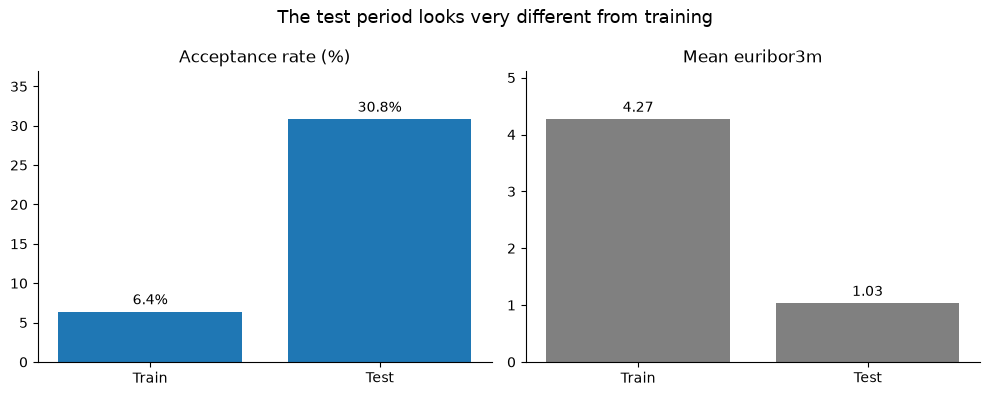

In [59]:
import matplotlib.pyplot as plt

acceptance = [train['y'].mean() * 100, test['y'].mean() * 100]
euribor = [train['euribor3m'].mean(), test['euribor3m'].mean()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

bars1 = ax1.bar(['Train', 'Test'], acceptance, color='#1f77b4')
ax1.bar_label(bars1, fmt='%.1f%%', padding=3)
ax1.set_title('Acceptance rate (%)')
ax1.set_ylim(0, max(acceptance) * 1.2)

bars2 = ax2.bar(['Train', 'Test'], euribor, color='grey')
ax2.bar_label(bars2, fmt='%.2f', padding=3)
ax2.set_title('Mean euribor3m')
ax2.set_ylim(0, max(euribor) * 1.2)

for ax in (ax1, ax2):
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('The test period looks very different from training', fontsize=13)
plt.tight_layout()
plt.savefig('chart_1_time_shift.png', dpi=200, bbox_inches='tight')
plt.show()

### Model Comparison

On the test period, logistic regression with economic variables has the highest raw PR-AUC and lift. It was still not selected: the final model (logistic regression without economic variables, shown in blue) was chosen on the validation period, where the economic-variable version ranked worse than random. The test results are shown for transparency, not as the basis for selection. Only PR-AUC and lift at 20% capacity are shown here; the full metric table is in the final model selection section.

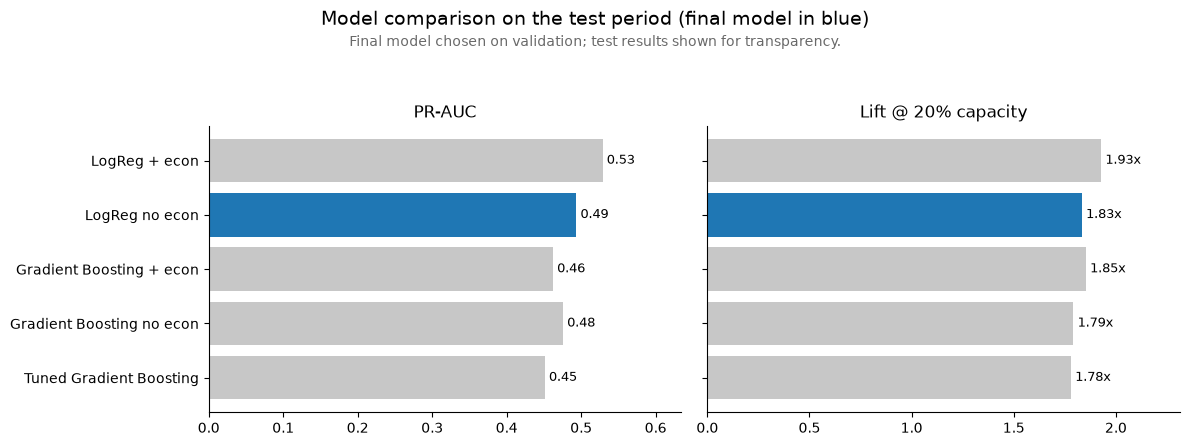

In [60]:
import matplotlib.pyplot as plt

final_model_name = 'LogReg no econ'
model_comparison = final_results_df.copy()

colors = [
    '#1f77b4' if m == final_model_name else '#c7c7c7'
    for m in model_comparison['model']
]

metrics = [
    ('pr_auc', 'PR-AUC', '{:.2f}'),
    ('lift@20', 'Lift @ 20% capacity', '{:.2f}x')
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (metric, title, fmt) in zip(axes, metrics):
    values = model_comparison[metric]
    bars = ax.barh(model_comparison['model'], values, color=colors)
    ax.bar_label(bars, labels=[fmt.format(v) for v in values], padding=3, fontsize=9)
    ax.set_title(title)
    ax.set_xlim(0, values.max() * 1.2)
    ax.invert_yaxis()
    ax.spines[['top', 'right']].set_visible(False)

axes[1].tick_params(labelleft=False)

fig.suptitle('Model comparison on the test period (final model in blue)', fontsize=14, y=0.98)
fig.text(
    0.5, 0.90,
    'Final model chosen on validation; test results shown for transparency.',
    ha='center', fontsize=10, color='dimgray'
)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig('chart_2_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

### Targeting Capacity Curve

The capacity analysis shows how the number of observed acceptances changes as NovaBank expands the share of customers targeted. The model-ranked strategy is compared with random selection at the same capacity. The 20% point represents the initial pilot capacity specified in the business problem, not a mathematically optimal long-term cutoff.

At the 20% pilot capacity, the model-ranked list produces noticeably more acceptances than random selection at the same contact volume. The exact figures are annotated on the chart and are calculated from the capacity table, so they update if the model changes.

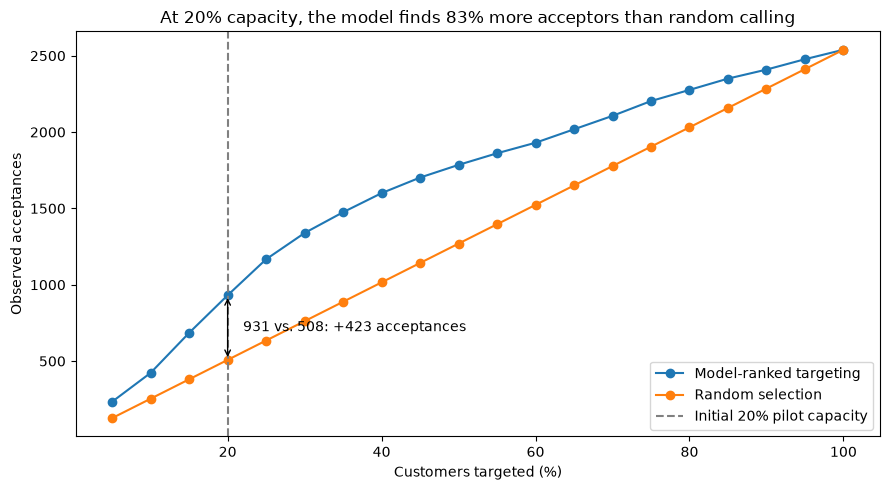

In [61]:
import numpy as np
import matplotlib.pyplot as plt

capacity_plot = v_final.copy()

# Pull the 20% figures from the data so the annotation updates with the model
row_20 = capacity_plot.loc[np.isclose(capacity_plot['capacity'], 0.20)].iloc[0]
model_20 = row_20['successes']
random_20 = row_20['random_successes']
gain_20 = model_20 - random_20

plt.figure(figsize=(9, 5))

plt.plot(
    capacity_plot['capacity'] * 100,
    capacity_plot['successes'],
    marker='o',
    label='Model-ranked targeting'
)

plt.plot(
    capacity_plot['capacity'] * 100,
    capacity_plot['random_successes'],
    marker='o',
    label='Random selection'
)

plt.axvline(
    20,
    linestyle='--',
    color='grey',
    label='Initial 20% pilot capacity'
)

plt.annotate(
    '',
    xy=(20, model_20),
    xytext=(20, random_20),
    arrowprops=dict(arrowstyle='<->', color='black')
)
plt.text(
    22, (model_20 + random_20) / 2,
    f'{model_20:,.0f} vs. {random_20:,.0f}: +{gain_20:,.0f} acceptances',
    va='center'
)

plt.xlabel('Customers targeted (%)')
plt.ylabel('Observed acceptances')
plt.title(
    f'At 20% capacity, the model finds {gain_20 / random_20:.0%} more acceptors than random calling'
)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('chart_3_capacity_curve.png', dpi=200, bbox_inches='tight')
plt.show()

### Value-to-Cost Sensitivity

The economically preferred targeting capacity changes substantially depending on the assumed value of a successful acceptance relative to the cost of contacting a customer. Because NovaBank has not provided actual campaign economics, these ratios are illustrative and should be treated as sensitivity scenarios rather than estimates of actual profit.

Each bar shows the range of capacities that come within 3% of the best net value for that ratio, and the black dot marks the single best point. The ranges matter more than the dots: at 5:1, anything from roughly 40% to 85% performs almost equally well, so the 75% point is not meaningful on its own. Only these four ratios were tested, so the chart does not connect them.

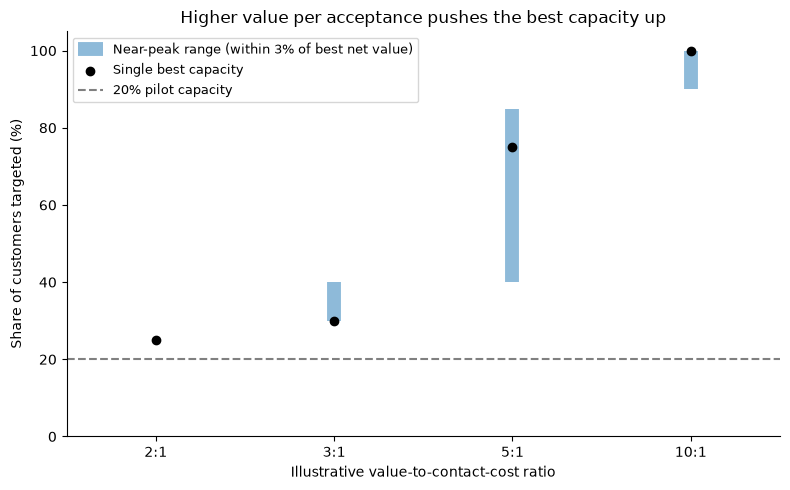

In [62]:
import matplotlib.pyplot as plt

r = ratio_results_final_df.reset_index(drop=True)
x = list(range(len(r)))

fig, ax = plt.subplots(figsize=(8, 5))

ax.vlines(
    x,
    r['near_peak_min_capacity'] * 100,
    r['near_peak_max_capacity'] * 100,
    linewidth=10,
    alpha=0.5,
    label=f'Near-peak range (within {near_peak_tolerance:.0%} of best net value)'
)
ax.scatter(
    x,
    r['best_capacity'] * 100,
    color='black',
    zorder=3,
    label='Single best capacity'
)
ax.axhline(20, linestyle='--', color='grey', label='20% pilot capacity')

ax.set_xticks(x)
ax.set_xticklabels([f'{v}:1' for v in r['value_cost_ratio']])
ax.set_xlim(-0.5, len(r) - 0.5)
ax.set_ylim(0, 105)
ax.set_xlabel('Illustrative value-to-contact-cost ratio')
ax.set_ylabel('Share of customers targeted (%)')
ax.set_title('Higher value per acceptance pushes the best capacity up')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('chart_4_value_cost.png', dpi=200, bbox_inches='tight')
plt.show()

## Pilot plan and key risks

### Pilot plan

**Scope.** One quarterly campaign run as a 90-day pilot. Before the campaign, score all eligible customers with the final model (logistic regression without economic variables), freeze the model, and contact the top-ranked customers up to the 20% call capacity. To measure the model's value directly, reserve about 10% of call capacity for a randomly selected comparison group drawn from all eligible customers. When scoring, set `day_of_week` to a single value for everyone, since the call day is not known at targeting time.

**KPIs.**
- Primary: acceptance rate in the model-targeted group relative to the random comparison group (realized lift). Within-month evaluation suggests a realistic range of about 1.2x (validation) to 1.65x (test); a realized lift of at least 1.2x would support continuing.
- Secondary: acceptances per 100 calls; cost per acceptance once NovaBank supplies contact costs and deposit value; targeting ratio and precision by age band and occupation.
- Proxy check: whether customers who accept a deposit are retained over the deposit term at a higher rate than comparable non-accepters.

**Timeline.**
- Weeks 1 to 2: score the customer base, draw the comparison group, compliance review of age-based selection, brief the call team.
- Weeks 3 to 10: campaign calls, with weekly tracking of acceptance rate, lift against the comparison group, and subgroup targeting ratios.
- Weeks 11 to 13: evaluate results; decide whether to keep, expand or reduce capacity using actual campaign economics; retrain on the new data before the next campaign.

### Key risks for executives

1. **Period instability.** The data shows large shifts between periods in economic conditions, customer mix and base acceptance rate (6.4% in training, 30.8% in test). Economic variables and month both changed direction between validation and test. Measured the way a real campaign works, within a single month, lift was 1.24x on validation and 1.65x on test, below the 1.83x headline figure, and the next campaign may differ again. *Mitigation:* the random comparison group gives a direct read on realized lift, and the model is retrained after each campaign.
2. **Proxy assumption.** The model predicts term-deposit acceptance, not retention. Accepting a fixed-term deposit is assumed to reduce the chance of leaving during the term, but this has not been tested in the data. *Mitigation:* track retention of accepters versus non-accepters during the pilot before treating acceptance as a retention outcome.
3. **Subgroup targeting differences.** Customers aged 66+ and retired customers are selected at about 2.0x the overall rate, while blue-collar customers are selected at about 0.4x. Precision is similar across age bands, so the model is not wasting calls on older customers, but the selection pattern needs compliance sign-off. *Mitigation:* compliance review before launch and subgroup monitoring after each campaign.

## AI usage log

| Date | Tool | What AI contributed | What I learned |
|---|---|---|---|
| _2026-10-01_ | _ChatGPT & Claude (Anthropic)_ | **Problem framing:** _Helped me think through how term-deposit acceptance could be used as a proxy for customer commitment and why a time-based split was more appropriate than a random split for data ordered chronologically._ | _A random split would mix earlier and later observations between training and testing, which would not reflect how the model would be used on future customers. A time-based split gives a more realistic test of whether the model can generalize to a later period_ |
| _2026-10-01_ | _ChatGPT_ | **Cleaning logic:** _Helped me investigate duplicates, the meaning of pdays = 999, and how to handle the default variable and contact_history._ | _The pdays crosstab showed me that 999 was not simply a missing value. Its meaning depended on whether the customer had been contacted before, so I needed to understand the data before deciding how to transform it._ |
| _2026-10-02_ | _ChatGPT_ | **Metric choice:** _Helped me assess why accuracy was not appropriate for the imbalanced target and why PR-AUC, precision@20%, recall@20%, and lift were more relevant to the targeting decision._ | _With only 11.3% of customers accepting the term deposit, a model that predicted "no" for almost everyone could achieve about 88.7% accuracy while being ineffective for targeting. The evaluation therefore needs to focus on how well the model identifies likely acceptors within the customers the bank can actually contact._ |
| 2026-10-03 | Claude (Anthropic) | Reviewed the notebook and flagged issues involving reproducibility, model-selection logic, the fairness calculation, the treatment of month, and hard-coded odds ratios. I assessed the feedback and decided which changes were justified before implementing them. | _I learned that a technically correct analysis can still be misleading if the notebook structure, calculations, or interpretation are inconsistent with the final methodology. I also learned to question whether a variable represents a useful customer characteristic or simply reflects when an observation occurred._ |
| 2026-10-04 | Claude (Anthropic) | Reviewed the notebook structure and suggested moving the validation comparison before final model selection, removing duplicate cells, correcting the targeting ratio, fixing the robustness calculation, adding sensitivity checks, and improving the capacity analysis. I implemented the relevant changes and reran the notebook to check the results. | _I learned that model selection needs to be separated from final test evaluation. The test set should remain untouched until the final evaluation, and supporting calculations should use the same final model and methodology as the main analysis._ |
| 2026-10-05 | Claude (Anthropic) | Reviewed the model's treatment of month and explained why it could represent a period effect rather than a useful within-campaign ranking signal. It also suggested improvements to the data dictionary, within-month evaluation, pilot plan, key risks, and project brief. I evaluated the suggestions, implemented the relevant changes, and checked how they affected the analysis and recommendations. | _I learned that a variable can appear highly predictive without being useful for the actual business decision. If customers in a future campaign are contacted during the same period, month cannot meaningfully distinguish which individual customers should be prioritized._ |
| 2026-10-06 | Claude (Anthropic) | Reviewed the four charts and flagged presentation problems with the train/test shift, model comparison, and value-to-cost sensitivity charts. I revised the charts and supporting text, organized them into a Visual Summary section, removed the remaining exploratory cells, and checked the notebook's final outputs. | _I learned that a technically correct chart can still communicate the wrong conclusion if its axes, colours, or comparison points are unclear. Visuals need to make the intended business interpretation clear without requiring the reader to reconstruct the analysis._ |